In [1]:
# IMPORT STATEMENTS
import sys
sys.path.append("/booleanfs2/sahoo/Hegemon/")
sys.path = ["/booleanfs2/sahoo/BoNE/"] + sys.path

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

try:
    reload  # Python 2.7
except NameError:
    try:
        from importlib import reload  # Python 3.4+
    except ImportError:
        from imp import reload  # Python 3.0 - 3.3
        
import SMaRT.MacUtils as mut
reload(mut)
import bone
reload(bone)

<module 'bone' from '/booleanfs2/sahoo/BoNE/bone.py'>

In [2]:
import cv2
import re
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable, axes_size
import matplotlib.patches as patches
import matplotlib.colors as colors
import PIL
import math
get_ipython().magic('matplotlib inline')
import pandas as pd
import seaborn as sns
import json
from scipy.stats import fisher_exact, ttest_ind
from collections import Counter
from pprint import pprint
import os
import pickle
import sys
# import plotnine as p9
#sys.path.append("/Users/dtv004/Daniella/data/BoNE")
#sys.path.append("BoNE")
#sys.path.append('/Users/dtv004/Daniella/data/BE/BoNE')
sys.path.append("/booleanfs/sahoo/scripts/")
sys.path.append("/booleanfs2/sahoo/Hegemon/")
import StepMiner as smn
import HegemonUtil as hu
acolor = ["#00CC00", "#D8A03D","#EC008C",
          'cyan', "#B741DC", "#808285",
          'blue', 'black', 'green', 'red',
          'orange', 'brown', 'pink', 'purple']

try:
    reload  # Python 2.7
except NameError:
    try:
        from importlib import reload  # Python 3.4+
    except ImportError:
        from imp import reload  # Python 3.0 - 3.3     

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# import gc_mod
# reload(gc_mod)
import bone
reload(bone)

<module 'bone' from '/booleanfs2/sahoo/BoNE/bone.py'>

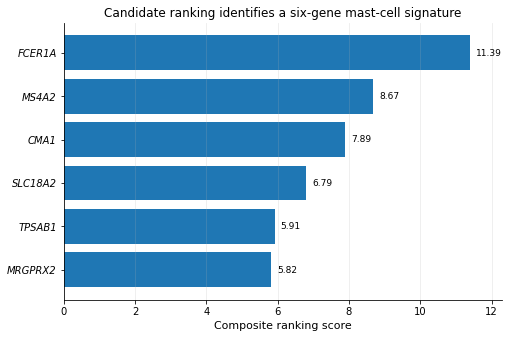

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df_rank = pd.read_csv("training/final_rank.csv", sep=",")
# plot_df = df_rank
# plot_df = (plot_df.sort_values("score", ascending=False).reset_index(drop=True))
plot_df = (df_rank.sort_values("score", ascending=False).head(6).reset_index(drop=True))

N_SIGNATURE = 6
fig, ax = plt.subplots(figsize=(7.2, 4.8))

bars = ax.barh(plot_df["GeneName"], plot_df["score"])

for i, bar in enumerate(bars):
    if i >= N_SIGNATURE:
        bar.set_alpha(0.35)

# Highest-ranking gene at the top
ax.invert_yaxis()
offset = plot_df["score"].max() * 0.015

for i, value in enumerate(plot_df["score"]):
    ax.text(value + offset, i, f"{value:.2f}", va="center", fontsize=9)
if len(plot_df) > N_SIGNATURE:
    cutoff_position = N_SIGNATURE - 0.5
    ax.axhline(y=cutoff_position,linestyle="--",linewidth=1)
    ax.text(plot_df["score"].max() * 0.98, cutoff_position - 0.12, "six-gene signature cutoff (lfc>2)", ha="right", va="bottom", fontsize=9)

ax.set_xlabel("Composite ranking score", fontsize=11)
ax.set_ylabel("")
ax.set_title("Candidate ranking identifies a six-gene mast-cell signature",fontsize=12)

for label in ax.get_yticklabels():
    label.set_fontstyle("italic")
    label.set_fontsize(10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

# horizontal space for score labels
ax.set_xlim(0,plot_df["score"].max() * 1.08)

plt.tight_layout()
plt.savefig("pdf-res/Figure2b_candidate_ranking.pdf",dpi=400,bbox_inches="tight")

plt.show()

In [4]:
def getMastSpecificSig():
    mast_specific_sig = ['FCER1A', 'MS4A2', 'CMA1', 'SLC18A2', 'TPSAB1', 'MRGPRX2']
    wt1, l1 = [1], [mast_specific_sig]
    return wt1, l1

In [ ]:
# (2c)

In [2]:
def getChhiba2017mm(self, tn=1):
    self.prepareData("M23", cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c cell type_ch1")
    atypes = ['non-Mast(baso)', 'Mast']
    ahash = {'Bone marrow-derived basophils':0, 'Bone marrow-derived mast cells':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getChhiba2017mm = getChhiba2017mm

def getBulfone2024MastRNASeq(self, tn=1):
    self.prepareData("M26", cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c cell type_ch1")
    atypes = ['non-Mast', 'Mast']
    ahash = {'CD45 Cells Excluding Mast Cells':0, 'Mast Cells':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getBulfone2024MastRNASeq = getBulfone2024MastRNASeq

Bulfone 2024 Mast Cells and CD45 (n = 40)
GSE196292 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M26
40 [15, 25] GSE196292 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M26 M26
[6]
Chhiba 2017 Mast Cells vs Basophils (n = 36)
GSE96696 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M23
36 [18, 18] GSE96696 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M23 M23
[11]


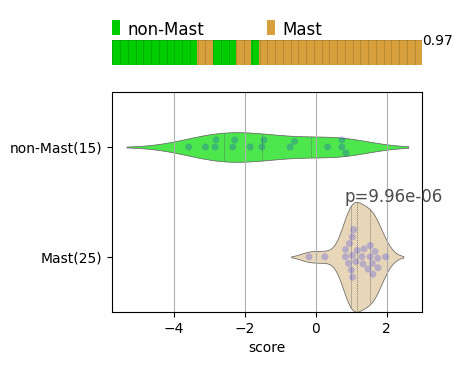

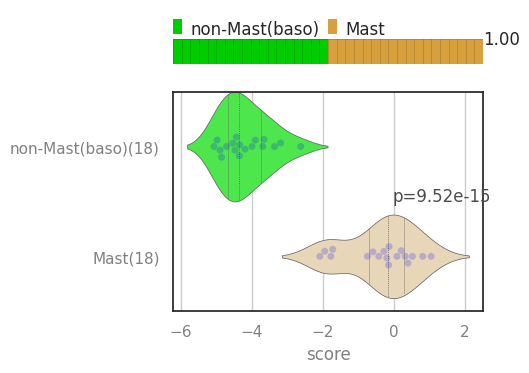

In [5]:
wt1, l1 = getMastSpecificSig()
ana = bone.IBDAnalysis()

ana.getBulfone2024MastRNASeq(1)
fig = bone.processData(ana, l1, wt1, desc=None, violin=1)
# plt.savefig("pdf-res/Figure2c-1_Bulfone_rnaSeq_Hs_GSE196292.pdf",dpi=400,bbox_inches="tight")

wt1, l1 = getMastSpecificSig()
l1 = mut.getGroupsMm(l1)
ana.getChhiba2017mm(1)
fig = bone.processData(ana, l1, wt1, desc=None, violin=1)
# plt.savefig("pdf-res/Figure2c-2_Chhiba_microarray_mm_MastBasoGSE96696.pdf",dpi=400,bbox_inches="tight")



In [33]:
#(2d)
# benchmark

In [21]:
def getYabeWada2019Mast(self, tn=1): # training
    self.prepareData("M51", cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c cell type_ch1")
    atypes = ['non-Mast', 'Eosinophils', 'Mast']
    ahash = {'Basophils':0, 'Eosinophils':1, 'Mast cells':2}
    if (tn==2):
        atypes = ['Baso/Eosino', 'Mast']
        ahash = {'Basophils':0, 'Eosinophils':0, 'Mast cells':1}
        
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getYabeWada2019Mast = getYabeWada2019Mast

def getChhiba2017mm(self, tn=1):
    self.prepareData("M23", cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c cell type_ch1")
    atypes = ['non-Mast(baso)', 'Mast']
    ahash = {'Bone marrow-derived basophils':0, 'Bone marrow-derived mast cells':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getChhiba2017mm = getChhiba2017mm

def getQiMastCellBasophilsMM(self, tn=1):
    self.prepareData("M52", cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c tissue_ch1")
    atypes = ['basophils', 'mast cell']
    ahash = {'purified basophils from bone marrow':0, 'basophil':0, 'mast cell derived from bone marrow':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getQiMastCellBasophilsMM = getQiMastCellBasophilsMM

def getBulfone2024MastRNASeq(self, tn=1):
    self.prepareData("M26", cfile="/Users/prisha.kaushik/public_html/Hegemon/explore.conf")
    atype = self.h.getSurvName("c cell type_ch1")
    atypes = ['non-Mast', 'Mast']
    ahash = {'CD45 Cells Excluding Mast Cells':0, 'Mast Cells':1}
    self.initData(atype, atypes, ahash)    
    return
bone.IBDAnalysis.getBulfone2024MastRNASeq = getBulfone2024MastRNASeq


In [22]:
wt1, l1 = getMastSpecificSig()
ana = bone.IBDAnalysis()

wt1, l1 = getMastSpecificSig()
l1 = mut.getGroupsMm(l1)
ana.getYabeWada2019Mast(2)
# fig = bone.processData(ana, l1, wt1, desc=None, violin=1)

wt1, l1 = getMastSpecificSig()
l1 = mut.getGroupsMm(l1)
ana.getChhiba2017mm(1) 
# fig = bone.processData(ana, l1, wt1, desc=None, violin=1)

wt1, l1 = getMastSpecificSig()
l1 = mut.getGroupsMm(l1)
ana.getQiMastCellBasophilsMM(1) 
# fig = bone.processData(ana, l1, wt1, desc=None, violin=1)

wt1, l1 = getMastSpecificSig()
ana.getBulfone2024MastRNASeq(1)
# fig = bone.processData(ana, l1, wt1, desc=None, violin=1)

Yabe-Wada 2019 Mast Cells vs Basophils vs Eosinophils (n = 10)
GSE87638 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M51
10 [8, 2] GSE87638 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M51 M51
Chhiba 2017 Mast Cells vs Basophils (n = 36)
GSE96696 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M23
36 [18, 18] GSE96696 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M23 M23
Qi Mast Cells and Basophils (n = 18)
GSE41596 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M52
18 [15, 3] GSE41596 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M52 M52
Bulfone 2024 Mast Cells and CD45 (n = 40)
GSE196292 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M26
40 [15, 25] GSE196292 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M26 M26


In [23]:
def getSig_1():
    f1 = "./geneSet/Sig_1_NAKAJIMA_MAST_CELL.txt"
    with open(f1) as file:
        Sig = [line.rstrip() for line in file]
    wt1, l1 = [1], [Sig]
    return wt1, l1
def getSig_2():
    f1 = "./geneSet/Sig_2_china.txt"
    with open(f1) as file:
        Sig = [line.rstrip() for line in file]
    wt1, l1 = [1], [Sig]
    return wt1, l1
def getSig_3():
    f1 = "./geneSet/Sig_3_GOBP_MAST_CELL_MIGRATION.txt"
    with open(f1) as file:
        Sig = [line.rstrip() for line in file]
    wt1, l1 = [1], [Sig]
    return wt1, l1
def getSig_4():
    f1 = "./geneSet/Sig_4_GOBP_REGULATION_OF_MAST_CELL_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE.txt"
    with open(f1) as file:
        Sig = [line.rstrip() for line in file]
    wt1, l1 = [1], [Sig]
    return wt1, l1
def getSig_5():
    f1 = "./geneSet/Sig_5_HP_ABNORMAL_MAST_CELL_MORPHOLOGY.txt"
    with open(f1) as file:
        Sig = [line.rstrip() for line in file]
    wt1, l1 = [1], [Sig]
    return wt1, l1
def getSig_6():
    f1 = "./geneSet/Sig_6_JONES_OVARY_MAST_CELL.txt"
    with open(f1) as file:
        Sig = [line.rstrip() for line in file]
    wt1, l1 = [1], [Sig]
    return wt1, l1
def getSig_7():
    f1 = "./geneSet/Sig_7_sc.txt"
    with open(f1) as file:
        Sig = [line.rstrip() for line in file]
    wt1, l1 = [1], [Sig]
    return wt1, l1
def getSig_8():
    f1 = "./geneSet/Sig_8_11Gene signature.txt"
    with open(f1) as file:
        Sig = [line.rstrip() for line in file]
    wt1, l1 = [1], [Sig]
    return wt1, l1
def getSig_9():
    f1 = "./geneSet/Sig_9_GOBP_MAST_CELL_ACTIVATION.txt"
    with open(f1) as file:
        Sig = [line.rstrip() for line in file]
    wt1, l1 = [1], [Sig]
    return wt1, l1
def getSig_10():
    f1 = "./geneSet/Sig_10_GOBP_MAST_CELL_ACTIVATION_INVOLVED_IN_IMMUNE_RESPONSE.txt"
    with open(f1) as file:
        Sig = [line.rstrip() for line in file]
    wt1, l1 = [1], [Sig]
    return wt1, l1
def getSig_11():
    f1 = "./geneSet/Sig_11_GOBP_MAST_CELL_DIFFERENTIATION.txt"
    with open(f1) as file:
        Sig = [line.rstrip() for line in file]
    wt1, l1 = [1], [Sig]
    return wt1, l1


In [27]:
def MASTcomparison(ana, org, desc=''):
    def getL(l1):
        return '(' + ",".join([str(len(k)) for k in l1]) +')'

    res = []
    
    wt1, l1 = getMastSpecificSig()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'BooleanDiscovery', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    wt1, l1 = getSig_1()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'S1', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    wt1, l1 = getSig_2()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'S2', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    wt1, l1 = getSig_3()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'S3', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    wt1, l1 = getSig_4()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'S4', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    wt1, l1 = getSig_5()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'S5', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    wt1, l1 = getSig_6()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'S6', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    wt1, l1 = getSig_7()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'S7', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    wt1, l1 = getSig_8()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'S8', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    wt1, l1 = getSig_9()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'S9', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    wt1, l1 = getSig_10()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'S10', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    wt1, l1 = getSig_11()
    ann = [re.sub(" .*", "", ana.h.getSource()), org, 'S11', getL(l1)]
    res += [ana.getStats(l1, wt1, ann)]
    
    cols = ['GSEID', 'ROC-AUC', 'pvalue', '#Cont', '#Expt',
            'Series', 'Species', 'Signature', '#Genes']
    df = pd.DataFrame(res, columns=cols)
    df['Condition'] = desc
    return df

# Run signatures for each dataset
res = []

ana.getYabeWada2019Mast(2)
desc = ana.atypes[0] + ' vs ' + ana.atypes[1]
res += [MASTcomparison(ana, org="Mm", desc=desc)]

ana.getChhiba2017mm(1) 
desc = ana.atypes[0] + ' vs ' + ana.atypes[1]
res += [MASTcomparison(ana, org="Mm", desc=desc)]

ana.getQiMastCellBasophilsMM(1)
desc = ana.atypes[0] + ' vs ' + ana.atypes[1]
res += [MASTcomparison(ana, org="Mm", desc=desc)]

ana.getBulfone2024MastRNASeq(1)
desc = ana.atypes[0] + ' vs ' + ana.atypes[1]
res += [MASTcomparison(ana, org="Hs", desc=desc)]

df = pd.concat(res)
df.to_csv("pdf-res/validation-results-2.txt", sep="\t")

Yabe-Wada 2019 Mast Cells vs Basophils vs Eosinophils (n = 10)
GSE87638 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M51
10 [8, 2] GSE87638 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M51 M51
[24]
[43]
[25]
[12]
[4]
[8]
[56]
[12]
[10]
[93]
[76]
[7]
Chhiba 2017 Mast Cells vs Basophils (n = 36)
GSE96696 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M23
36 [18, 18] GSE96696 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M23 M23
[11]
[51]
[29]
[21]
[8]
[6]
[59]
[11]
[9]
[102]
[78]
[9]
Qi Mast Cells and Basophils (n = 18)
GSE41596 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M52
18 [15, 3] GSE41596 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M52 M52
[9]
[49]
[22]
[13]
[4]
[9]
[43]
[15]
[10]
[88]
[66]
[7]
Bulfone 2024 Mast Cells and CD45 (n = 40)
GSE196292 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M26
40 [15, 25] GSE196292 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=M26 M26
[6]
[46]
[20]
[13]
[5]
[8]
[

In [28]:
def DP1(dfs): # VERTICAL

    if len(dfs) <= 0:
        return None
    df1 = dfs[0]
    df1['Name'] = list(df1['Signature'])
    df1['Xl'] = list(df1['#Genes'])
    labels = [k['GSEID'][0] + ' ' + k['Condition'][0] for k in dfs]
    n1 = df1.shape[0]
    rocauc = list(df1['ROC-AUC'])
    p = list(df1['pvalue'])
    y = [1] * n1
    for i in range(1, len(dfs)):
        rocauc += list(dfs[i]['ROC-AUC'])
        p += list(dfs[i]['pvalue'])
        y += [i+1] * n1
    df = pd.DataFrame()
    df['ROC-AUC'] = rocauc
    df['pvalue'] = p
    df['ROC-AUC'] = df['ROC-AUC'].apply(
               lambda x: max([float(k) for k in str(x).split(",")]))
    df['pvalue'] = df['pvalue'].apply(
               lambda x: min([float(k) for k in str(x).split(",")]))
    df['Y'] = y
    df['R'] = [(i - 0.5) if i !=200  else 200  for i in df['ROC-AUC']]      #df['ROC-AUC'] - 0.5
    df['Ra'] = [abs(i)+ 0.5  if i<1  else 0  for i in df['R'] ]     # abs(df['R']) + 0.5
    df['Ra1'] = [abs(i)+ 0.5  if i<1  else 0.51 if i==0 else 0.48  for i in df['R'] ]

    df['AUC'] = ['Up' if i > 0 else 'Down' for i in df['R']]
    #['Up' if i > 0 else 'Down' if i!=0 else 'NP' for i in df['R']]
    df['code'] = [bone.getCode(i) for i in df['pvalue']]
    df['ROC-AUC'] = df['Ra1']
    sns.set()
    sns.set_style("white")
    sns.set_style({'xtick.color':'.5', 'ytick.color':'.5', 'axes.labelcolor': '.5'})
    sns.set_context("notebook")
    sns.set_palette([bone.adj_light(c, 0.7, 1) for c in ['red', 'blue']])
    x = [i + 1 for i in range(n1)] * len(labels)
    y = df['Y']
    fig, ax = plt.subplots(figsize=(12, len(dfs)*0.7+1), dpi=100)
    ax = sns.scatterplot(x=x, y=y, size="ROC-AUC", hue='AUC',
                         sizes = (0, 100), size_norm = (0.49, 1),
                         hue_order = ['Up', 'Down'], ax=ax, data=df);
    roc = list(df['Ra'])
    code = list(df['code'])
    for line in range(n1):
        ax.text(line + 1, len(labels) + .5, df1['Xl'][line],
                horizontalalignment='center', size='small', color='0.8',
                verticalalignment='bottom', rotation=90)
        for i in range(len(labels)):
            ax.text(line + 1, i + 0.9, "%.2f" % roc[line + n1 * i],
                    horizontalalignment='right', size='small', color='0.8',
                    verticalalignment='top',  rotation=90)
            ax.text(line + 1.5, i + 0.9, code[line + n1 * i],
                     horizontalalignment='right', size='small', color='0.8',
                     verticalalignment='top',  rotation=90)

    x1 = [i + 1 for i in range(n1)]
    ax.set_yticks(range(1, len(labels) + 1))
    ax.set_yticklabels(labels)
    ax.set_xlim([0, len(x1)+1])
    ax.set_ylim([0, len(labels) + 2])
    ax.set_xticks(x1)
    ax.set_xticklabels(df1['Name'], rotation=90)
    ax.set_ylabel("")
    ax.grid(False)
    handles, labels = ax.get_legend_handles_labels()
#     labels[4] = '0.5'
    ax.legend(handles, labels, bbox_to_anchor=(1.3, 1))

    return df,ax,fig

Condition  Baso/Eosino vs Mast  basophils vs mast cell  non-Mast vs Mast  \
0                         0.88                    0.91              0.97   
8                         1.00                    0.67              0.98   
7                         0.88                    0.29              0.98   
11                        1.00                    1.00              0.45   
3                         1.00                    0.47              0.81   
4                         0.44                    0.51              0.87   
9                         0.88                    0.00              0.86   
10                        0.81                    0.00              0.90   
1                         0.81                    0.00              0.99   
6                         0.75                    0.07              0.68   
5                         0.75                    0.00              0.54   
2                         0.06                    0.00              0.96   

Condition  

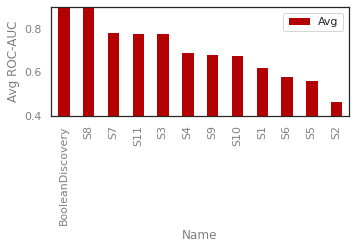

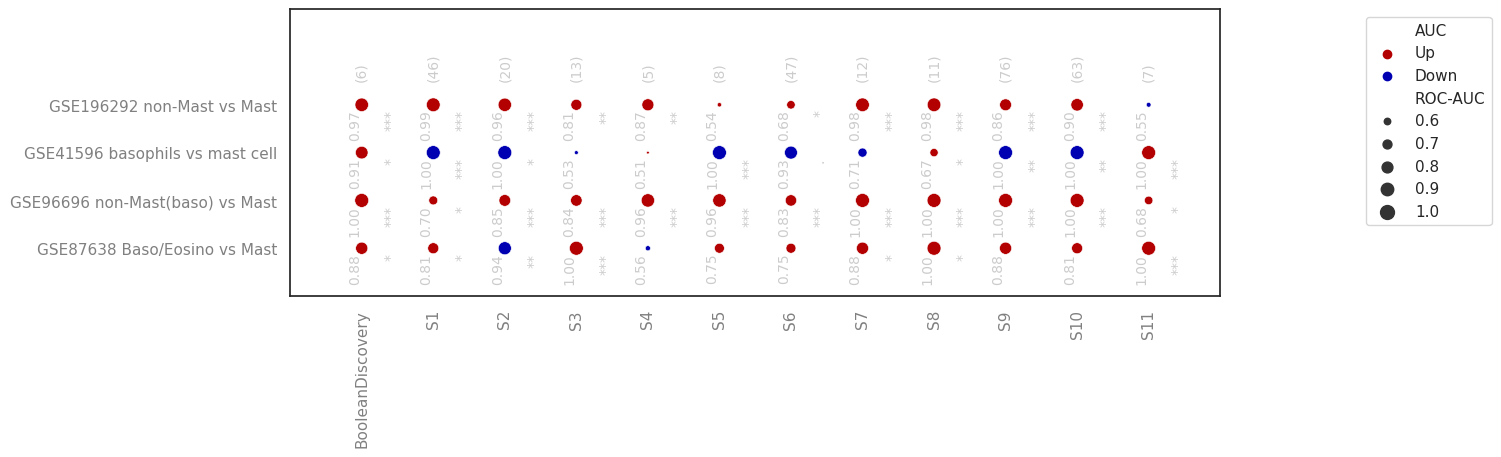

In [29]:
nsig = 11 # CHANGE to match # of sigs 

df = pd.read_csv("pdf-res/validation-results-2.txt", sep="\t", index_col=0)
res = np.array_split(df, df.shape[0]/nsig, axis=0)

df1 = df.pivot_table(values='ROC-AUC', index=df.index, columns='Condition', aggfunc='last')
df1['Avg'] = df1.apply(pd.to_numeric).mean(axis=1)
df1['Name'] = [df.iloc[k, df.columns.get_loc("Signature")] for k in df1.index]
df1 = df1.sort_values('Avg', ascending=False)
ax = df1.plot.bar(x='Name', y='Avg', figsize=(2*24/9, 2))
ax.set_ylim([0.4, 0.9])
ax.set_ylabel("Avg ROC-AUC")
print(df1)
df,ax,fig = DP1(res)
strname = "dot_plots"
fig.savefig(f'pdf-res/Figure2D-_{strname}.pdf', dpi=100, transparent=True,bbox_inches = 'tight')

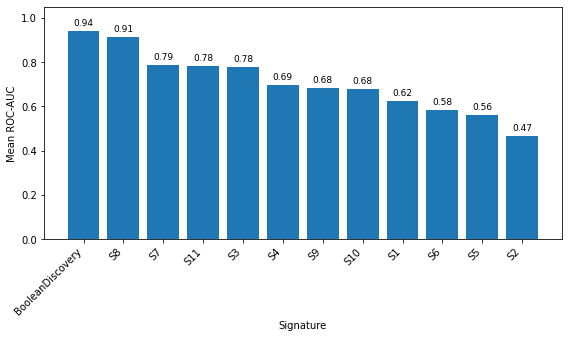

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pdf-res/validation-results-2.txt", sep="\t", index_col=0)

# avg_auc = (df.groupby("Signature", as_index=False)["ROC-AUC"].mean())
sig_order = ["BooleanDiscovery"] + [f"S{i}" for i in range(1, 12)]

avg_auc = (
    df.groupby("Signature", as_index=False)["ROC-AUC"]
      .mean()
      .sort_values("ROC-AUC", ascending=False)
      .reset_index(drop=True))

# avg_auc = avg_auc.sort_values("Signature").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(avg_auc["Signature"],avg_auc["ROC-AUC"])
for bar, value in zip(bars, avg_auc["ROC-AUC"]):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.015, f"{value:.2f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Mean ROC-AUC")
ax.set_xlabel("Signature")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
strname = "avg-roc-auc"
fig.savefig(f'pdf-res/Figure2D-_{strname}.pdf', dpi=100, transparent=True,bbox_inches = 'tight')